# Error Analysis — ARC-Challenge

**Benchmark:** ARC-Challenge
**Description:** Grade-school science; multiple-choice 1-of-4
**Random baseline:** 25%
**Our generator(s) targeting this:** Gen A (Factual QA), targeted science content

This notebook drills into why the model isn't getting a higher score. It:
1. Splits every question into `answerable` / `unanswerable` / `ambiguous` using a hybrid keyword + LLM-judge classifier (cached).
2. Reports accuracy stratified by answerability — so we see real model capability, not just raw score.
3. Examines confidence on wrong answers (high-confidence wrong = learned wrong pattern).
4. Surfaces the highest-confidence wrong answers on the *answerable* subset — these are the diagnostic gold.
5. Compares Mid vs SFT phases to see where the gap closed or opened.
6. Delivers a one-line verdict: content gap, skill gap, or both.

In [2]:
import sys
from pathlib import Path

# Ensure project root is importable
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src" / "post_training").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.post_training.analysis import (
    load_details, load_classifications, classify_batch,
    accuracy_triple, confidence_breakdown, high_confidence_wrong,
    plot_confidence_histogram, extract_stem_and_choices,
)
from src.post_training.analysis.answerability import _hash_question

plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (12, 5)

BENCHMARK = "ARC-Challenge"
RANDOM_BASELINE = 0.25

BASE = Path(r'D:/hist_LLM/periods/1900_1949/error_analysis_new')
CACHE = BASE / '.answerability_cache' / f'{BENCHMARK}.jsonl'

STAGES = ['mid_final', 'sft_final', 'sft_final_debiased']
dfs = {}
for stage in STAGES:
    p = BASE / stage / f'{BENCHMARK}_details.jsonl'
    dfs[stage] = load_details(p)
    print(f'{stage}: {len(dfs[stage])} rows')

mid_final: 296 rows
sft_final: 296 rows
sft_final_debiased: 296 rows


## 1. Answerability Classifications

Load the cached classifications. If the cache is missing, build it now.
(Classifier is hybrid: keyword filter first, then LLM judge for the ambiguous middle.)

In [3]:
classes = load_classifications(CACHE)
print(f'Cached classifications: {len(classes)}')

if len(classes) < len(dfs['mid_final']):
    print('Cache incomplete — building now...')
    questions = []
    for i, row in dfs['mid_final'].iterrows():
        questions.append({'index': int(row['index']), 'question': row['question']})
    classify_batch(questions, CACHE, start_year=1900, end_year=1949)
    classes = load_classifications(CACHE)
    print(f'Now cached: {len(classes)}')

from collections import Counter
label_counts = Counter(r['label'] for r in classes.values())
print(f'\nLabel distribution: {dict(label_counts)}')

Cached classifications: 296

Label distribution: {'answerable': 268, 'unanswerable': 28}


## 2. Accuracy Stratified by Answerability

The headline question: **on the subset the model COULD answer with period knowledge, how well does it do?**

In [4]:
rows = []
for stage in STAGES:
    if dfs[stage].empty: continue
    trip = accuracy_triple(dfs[stage], classes)
    for bucket, stats in trip.items():
        if stats['acc'] is None: continue
        rows.append({
            'stage': stage, 'bucket': bucket,
            'n': stats['n'], 'correct': stats['correct'],
            'acc_%': round(100 * stats['acc'], 1),
            'vs_random_%': round(100 * (stats['acc'] - RANDOM_BASELINE), 1),
        })
summary = pd.DataFrame(rows)
print(f'Random baseline: {100*RANDOM_BASELINE:.0f}%')
summary

Random baseline: 25%


,stage,bucket,n,correct,acc_%,vs_random_%
0,mid_final,overall,296,100,33.8,8.8
1,mid_final,answerable,268,88,32.8,7.8
2,mid_final,unanswerable,28,12,42.9,17.9
3,sft_final,overall,296,94,31.8,6.8
4,sft_final,answerable,268,83,31.0,6.0
5,sft_final,unanswerable,28,11,39.3,14.3
6,sft_final_debiased,overall,296,93,31.4,6.4
7,sft_final_debiased,answerable,268,83,31.0,6.0
8,sft_final_debiased,unanswerable,28,10,35.7,10.7


## 3. Answerability Sanity Check

A sample of how the classifier labeled individual questions.

In [5]:
# Show 4 examples from each label
df_with_labels = dfs['mid_final'].copy()
df_with_labels['qhash'] = df_with_labels['question'].map(_hash_question)
df_with_labels['label'] = df_with_labels['qhash'].map(lambda h: classes.get(h,{}).get('label','ambiguous'))
df_with_labels['reason'] = df_with_labels['qhash'].map(lambda h: classes.get(h,{}).get('reason',''))
for label in ['answerable','unanswerable','ambiguous']:
    subset = df_with_labels[df_with_labels['label'] == label]
    if len(subset) == 0: continue
    print(f'=== {label.upper()} ({len(subset)} total) — sampling 3 ===')
    for _, row in subset.sample(min(3, len(subset)), random_state=42).iterrows():
        parsed = extract_stem_and_choices(row['question'])
        print(f'  Q: {parsed["stem"][:500]}')
        if row['reason']: print(f'     reason: {row["reason"][:500]}')
    print()

=== ANSWERABLE (268 total) — sampling 3 ===
  Q: Which statement explains why most salmon leave salt water and return to fresh water?
     reason: The question pertains to basic biological concepts about salmon behavior that were understood in the early 20th century.
  Q: Which statement concerning metals is correct?
     reason: The properties of metals, including their conductivity and structure, were well understood during 1900-1949.
  Q: Polar bears are very heavy. About half of a polar bear's mass is fat. How does this adaptation most help a polar bear as it hunts in the Arctic Ocean?
     reason: The concepts of polar bear biology and adaptations were known during 1900-1949.

=== UNANSWERABLE (28 total) — sampling 3 ===
  Q: As early as the 1600s, scientists noticed that the continents appeared to fit together like pieces of a puzzle. The idea that the continents were once together and had drifted apart was not widely accepted. In the 1940s, technology used on submarines led to e

## 4. Confidence Distribution

Right vs wrong, split by answerability. High-confidence wrong on the *answerable* subset = model learned a wrong pattern.

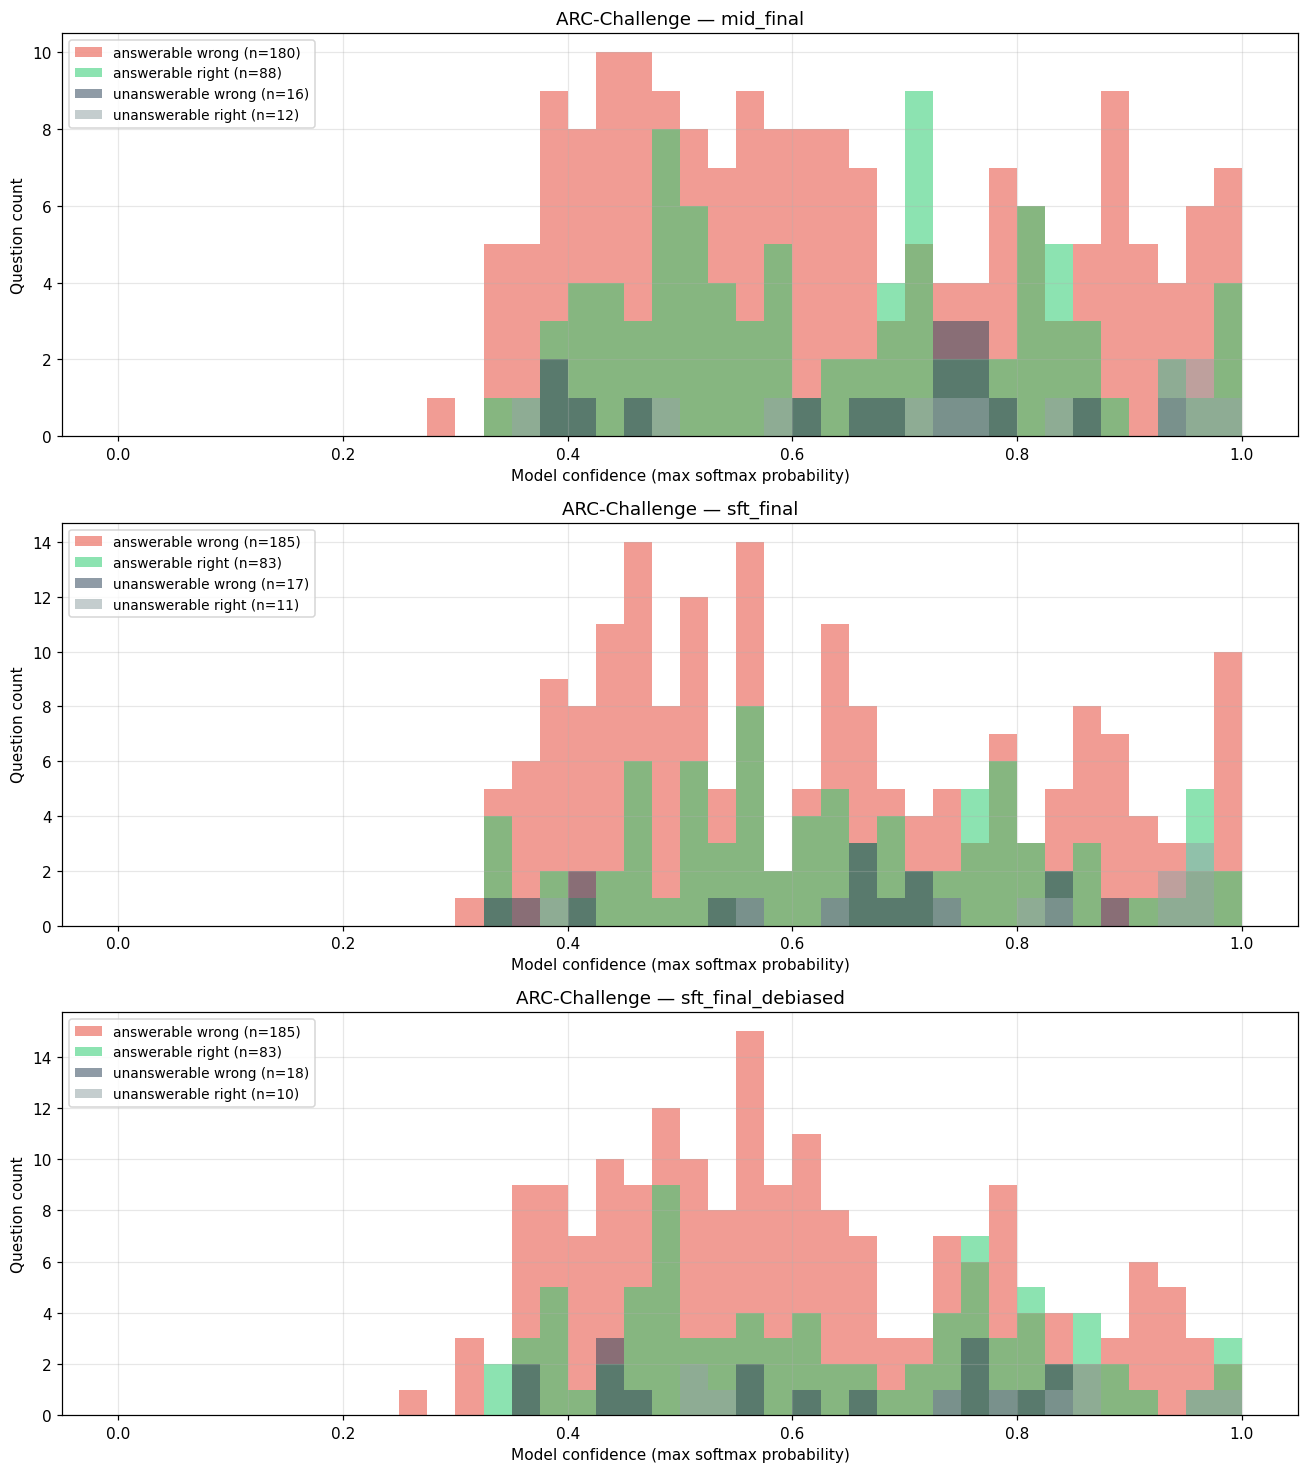

In [5]:
fig, axes = plt.subplots(len([s for s in STAGES if not dfs[s].empty]), 1, figsize=(12, 4.5*len([s for s in STAGES if not dfs[s].empty])))
axes = [axes] if not hasattr(axes, '__iter__') else axes
ax_iter = iter(axes)
for stage in STAGES:
    if dfs[stage].empty: continue
    ax = next(ax_iter)
    plot_confidence_histogram(dfs[stage], classes, title=f'{BENCHMARK} — {stage}', ax=ax)
plt.tight_layout()
plt.show()

## 5. High-Confidence Wrong Answers (answerable subset, Mid phase)

The diagnostic gold. These are questions the model should be able to answer using 1900-1949 knowledge, but got confidently wrong. Review these to identify patterns.

In [6]:
wrong = high_confidence_wrong(dfs['mid_final'], classes, label_filter='answerable', n=20, min_conf=0.5)
print(f'{len(wrong)} high-confidence wrong answers on the answerable subset\n')

for i, (_, row) in enumerate(wrong.iterrows(), 1):
    parsed = extract_stem_and_choices(row['question'])
    print(f'[{i:02d}] conf={row["confidence"]:.0%} pred={row["predicted"]} expected={row["expected"]}')
    print(f'     Q: {parsed["stem"][:280]}')
    for L in sorted(parsed['choices'].keys()):
        mark = ' ← PREDICTED' if L == row['predicted'] else (' ← CORRECT' if L == row['expected'] else '')
        print(f'       {L}: {parsed["choices"][L][:160]}{mark}')
    print()

20 high-confidence wrong answers on the answerable subset

[01] conf=100% pred=A expected=C
     Q: A brand of fertilizer claims that it contains all the chemicals a plant needs for rapid growth. It may be inferred that the fertilizer includes all these ingredients except
       A: potassium. ← PREDICTED
       B: phosphorus.
       C: carbohydrates. ← CORRECT
       D: nitrogen.

[02] conf=99% pred=A expected=D
     Q: A scientist categorized a rock as an extrusive igneous rock. Another scientist could accurately categorize the same rock as
       A: intrusive igneous. ← PREDICTED
       B: clastic sedimentary.
       C: metamorphic.
       D: volcanic. ← CORRECT

[03] conf=99% pred=B expected=D
     Q: A particular peach tree produces peaches that are more resistant to disease than other peaches. What method would reproduce these exact peaches?
       A: use bees to pollinate the flowers
       B: reproduce by cross-pollination of different peach trees ← PREDICTED
       C: increase 

## 6. Mid vs SFT on Answerable Subset

Did SFT help on the answerable slice, or did it just overfit to internal distribution?

In [7]:
if not dfs['sft_final'].empty:
    mid_trip = accuracy_triple(dfs['mid_final'], classes)
    sft_trip = accuracy_triple(dfs['sft_final'], classes)
    deb_trip = accuracy_triple(dfs['sft_final_debiased'], classes) if not dfs['sft_final_debiased'].empty else None
    rows = []
    for bucket in ['overall','answerable','unanswerable']:
        m = mid_trip.get(bucket,{}).get('acc')
        s = sft_trip.get(bucket,{}).get('acc')
        d = (deb_trip.get(bucket,{}).get('acc') if deb_trip else None)
        if m is None or s is None: continue
        rows.append({
            'bucket': bucket, 'n': mid_trip[bucket]['n'],
            'Mid_%': round(100*m,1), 'SFT_%': round(100*s,1),
            'Debiased_%': round(100*d,1) if d is not None else None,
            'SFT-Mid_delta': round(100*(s-m),1),
        })
    pd.DataFrame(rows)

## 7. Error-Type Clustering

What kinds of questions (within the answerable subset) does the model miss most?

In [8]:
# ARC-Challenge: cluster by science topic keyword
import re
SCIENCE_TOPICS = {
    'physics/energy': r'\b(energy|force|motion|gravity|electric|current|voltage|circuit|magnet|heat|temperature|light|sound|wave|mass|velocity|friction|pressure|power|watt|volt)\b',
    'biology/life': r'\b(cell|plant|animal|organism|ecosystem|food chain|photosynthesis|respiration|reproduction|dna|gene|species|bacteria|evolution|skeleton|muscle|organ|nerve|blood)\b',
    'chemistry/matter': r'\b(atom|molecule|element|compound|acid|base|solution|mixture|chemical|reaction|metal|liquid|solid|gas|crystal|salt|oxygen|hydrogen|carbon)\b',
    'earth/weather': r'\b(weather|climate|storm|rain|snow|wind|cloud|earth|rock|soil|mountain|ocean|river|volcano|earthquake|planet|moon|sun|star|season)\b',
}

wrong_df = dfs['mid_final'][dfs['mid_final']['correct'] == False].copy()
wrong_df['qhash'] = wrong_df['question'].map(_hash_question)
wrong_df['label'] = wrong_df['qhash'].map(lambda h: classes.get(h,{}).get('label','ambiguous'))
ans_wrong = wrong_df[wrong_df['label']=='answerable']

for topic, pat in SCIENCE_TOPICS.items():
    hits = ans_wrong[ans_wrong['question'].str.contains(pat, case=False, regex=True, na=False)]
    print(f'{topic}: {len(hits)} answerable wrong (of {len(ans_wrong)})')
    if len(hits):
        sample = hits.iloc[0]
        parsed = extract_stem_and_choices(sample['question'])
        print(f'  example: {parsed["stem"][:180]}')
    print()

physics/energy: 67 answerable wrong (of 180)
  example: Current moving through a circuit is stopped with a

biology/life: 28 answerable wrong (of 180)
  example: A student wants to determine which hand soap kills more bacteria. Her teacher tells her to change only the type of hand soap. The type of bacterium tested must be the same. Only on

chemistry/matter: 38 answerable wrong (of 180)
  example: Estuaries are dynamic ecosystems where salt water and fresh water mix. Usually this happens as fresh water flows from a river to an ocean. When would you expect the concentration o

earth/weather: 56 answerable wrong (of 180)
  example: Which weather event is most likely to cause a forest fire?



C:\Users\danielyoon\AppData\Local\Temp\ipykernel_30660\3141133296.py:16: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  hits = ans_wrong[ans_wrong['question'].str.contains(pat, case=False, regex=True, na=False)]


## 8. Verdict

Interpretation based on the answerable-subset accuracy:

- **answerable_acc > random + 15pp**: Real skill transfer. Model has the capability.
- **answerable_acc within ±5pp of random**: Skill gap. The model can't reason about even period-compatible content.
- **answerable_acc >> overall_acc**: Content gap dominates. Targeted synthetic data on modern vocabulary could help.
- **high-conf wrong clusters around one error type**: Targeted fix possible — rewrite the corresponding generator.

In [9]:
# Verdict computation
trip = accuracy_triple(dfs['mid_final'], classes)
overall = trip.get('overall', {}).get('acc', 0) or 0
answerable = trip.get('answerable', {}).get('acc', 0) or 0
unanswerable = trip.get('unanswerable', {}).get('acc', 0) or 0

verdict = []
if answerable > RANDOM_BASELINE + 0.15:
    verdict.append(f'✅ Real skill transfer: answerable={100*answerable:.1f}% vs random={100*RANDOM_BASELINE:.0f}%')
elif abs(answerable - RANDOM_BASELINE) < 0.05:
    verdict.append(f'⚠️ Skill gap: answerable subset at {100*answerable:.1f}% (near random).')
else:
    verdict.append(f'➖ Modest transfer: answerable={100*answerable:.1f}%, +{100*(answerable-RANDOM_BASELINE):.1f}pp vs random.')

if answerable - overall > 0.05:
    verdict.append(f'📈 Content gap contributes: answerable ({100*answerable:.1f}%) beats overall ({100*overall:.1f}%) by {100*(answerable-overall):.1f}pp.')

if unanswerable > RANDOM_BASELINE + 0.05:
    verdict.append(f'⚠️ Unanswerable subset at {100*unanswerable:.1f}% — model may be leaking modern knowledge.')

print('\n'.join(verdict))

➖ Modest transfer: answerable=32.8%, +7.8pp vs random.
⚠️ Unanswerable subset at 42.9% — model may be leaking modern knowledge.
